In [ ]:
import subprocess, sys
pkgs = ["scikit-learn","xgboost","lightgbm","imbalanced-learn","optuna","shap",
        "scipy","statsmodels"]
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"--quiet"], check=False)
print("Packages ready ✓")


Packages ready ✓


## Phase 1 — Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings, os, json
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
from statsmodels.stats.contingency_tables import mcnemar


DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Source_File_combined_2020_2023.csv"
DIR_PATH  = "Historic and Current Combined - Simplified.csv"


TRAIN_YEARS = [2014, 2015, 2016, 2017]
VAL_YEAR    = 2018
TEST_YEAR   = 2019
ALL_YEARS   = TRAIN_YEARS + [VAL_YEAR, TEST_YEAR]


SEED        = 42
N_BOOTSTRAP = 1000
N_TRIALS    = 4
ENCODING    = "latin-1"


REQUIRED_FIELDS  = ["vat", "bookyear", "ta", "net_income", "total_debt",
                    "current_assets", "st_debt"]
MAX_DEBT_TO_TA   = 100.0
MIN_TA           = 0.0


SAMPLE_MODE = False
SAMPLE_ROWS = 500_000


OUT_DIR = os.getenv("OUT_DIR", ".")
os.makedirs(OUT_DIR, exist_ok=True)

np.random.seed(SEED)
print("Config loaded ✓")
print(f"  Train years : {TRAIN_YEARS}")
print(f"  Val year    : {VAL_YEAR}")
print(f"  Test year   : {TEST_YEAR}")
print(f"  Cleaning    : ta>{MIN_TA}, no missing {REQUIRED_FIELDS}, |debt/ta|≤{MAX_DEBT_TO_TA}")
print(f"  Sample mode : {SAMPLE_MODE}")
print(f"  Output dir  : {OUT_DIR}")


Config loaded ✓
  Train years : [2014, 2015, 2016, 2017]
  Val year    : 2018
  Test year   : 2019
  Cleaning    : ta>0.0, no missing ['vat', 'bookyear', 'ta', 'net_income', 'total_debt', 'current_assets', 'st_debt'], |debt/ta|≤100.0
  Sample mode : False
  Output dir  : .


In [ ]:
from pathlib import Path
import pandas as pd

def count_physical_csv_rows(path: str | Path) -> int:
    """
    Counts physical data rows in a CSV.
    Assumes first line is the header.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    line_count = 0
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            line_count += chunk.count(b"\n")


    with path.open("rb") as f:
        f.seek(0, 2)
        if f.tell() > 0:
            f.seek(-1, 2)
            if f.read(1) != b"\n":
                line_count += 1


    return max(line_count - 1, 0)


def audit_dataset_rows(paths, years=None, bookyear_col="bookyear", encoding="latin1", chunksize=250_000):
    """
    Counts what the notebook is actually reading from the financial dataset.
    """
    if isinstance(paths, (str, Path)):
        paths = [Path(paths)]
    else:
        paths = [Path(p) for p in paths]

    rows = []

    for path in paths:
        path = Path(path)

        physical_rows = count_physical_csv_rows(path)
        pandas_rows = 0
        year_filtered_rows = 0

        for chunk in pd.read_csv(
            path,
            usecols=[bookyear_col],
            chunksize=chunksize,
            encoding=encoding,
            low_memory=False
        ):
            pandas_rows += len(chunk)

            if years is not None:
                chunk[bookyear_col] = pd.to_numeric(chunk[bookyear_col], errors="coerce")
                year_filtered_rows += chunk[chunk[bookyear_col].isin(years)].shape[0]

        rows.append({
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1e6, 1),
            "physical_csv_rows": physical_rows,
            "pandas_read_rows": pandas_rows,
            "rows_after_year_filter": year_filtered_rows if years is not None else None,
        })

    audit = pd.DataFrame(rows)

    total = {
        "file": "TOTAL",
        "size_mb": audit["size_mb"].sum(),
        "physical_csv_rows": audit["physical_csv_rows"].sum(),
        "pandas_read_rows": audit["pandas_read_rows"].sum(),
        "rows_after_year_filter": audit["rows_after_year_filter"].sum() if years is not None else None,
    }

    audit = pd.concat([audit, pd.DataFrame([total])], ignore_index=True)
    return audit

In [ ]:
audit_dataset_rows(
    DATA_PATH,
    years=ALL_YEARS,
    bookyear_col="bookyear",
    encoding=ENCODING
)

,file,size_mb,physical_csv_rows,pandas_read_rows,rows_after_year_filter
0,Source_File_combined_2020_2023.csv,3608.1,4502867,4502867,2446264
1,TOTAL,3608.1,4502867,4502867,2446264


In [ ]:
COLS_LOAD = [

    "vat", "bookyear",

    "fail_dummy", "jaar_van_faling",

    "ta", "net_income", "total_debt", "current_assets", "st_debt",
    "fin_debt_LT", "intangibles",

    "rub9901", "rub9087", "rub10_15", "rub70_74",

    "size", "age", "age_in_years",

    "laat_dummy", "aantal_dagen", "som_laat_totaal",
    "move_rate", "boete_dummy", "dgrmovestreet",

    "industry", "rechtsvorm", "nature",
]


def normalize_vat_series(s, label="vat"):
    """Canonicalise Belgian VAT/CBE numbers to the official 10-digit form.

    Belgian KBO/CBE numbers are 10 digits. Older companies (issued before
    2008) have 9-digit ondernemingsnummers padded with a leading '0';
    newer companies have a 10-digit number starting with '1'. Different
    data exports use either form. To merge safely, we canonicalise to the
    10-digit zero-padded form:

      - 'BE0400000284' / '0400000284' / '400000284'  →  0400000284 (10 digits)
      - 'BE1234567890' / '1234567890'                →  1234567890 (10 digits)

    Empty / non-numeric values are returned as pandas NA so the cleaning
    step catches them instead of collapsing them onto vat=0.

    `label` is printed in the audit line so the financial-file and the
    director-file calls can be compared side by side and any cross-file
    format mismatch is loud.
    """
    digits = (s.astype(str)
                .str.upper()
                .str.replace(r"[^0-9]", "", regex=True))
    lens = digits.str.len()
    if len(lens):
        dist = lens.value_counts().sort_index().to_dict()
        print(f"[vat-normalize:{label}] digit-length distribution: {dist}")

        bad_lens = {k: v for k, v in dist.items() if k not in (0, 9, 10)}
        if bad_lens:
            print(f"[vat-normalize:{label}] WARNING — unexpected digit lengths {bad_lens};"
                  " these will be coerced to NA.")


    digits = digits.where(digits.str.len() > 0, other=pd.NA)
    canon = pd.Series(pd.NA, index=digits.index, dtype="object")
    nine = digits.str.len() == 9
    ten  = digits.str.len() == 10
    canon[nine] = "0" + digits[nine]
    canon[ten]  = digits[ten]
    return pd.to_numeric(canon, errors="coerce").astype("Int64")

def load_financial(path, years, encoding=ENCODING,
                   sample_mode=False, sample_rows=500_000):
    chunks, seen = [], 0
    for chunk in pd.read_csv(path,
                             usecols=lambda c: c in set(COLS_LOAD),
                             chunksize=100_000,
                             encoding=encoding,
                             low_memory=False):
        sub = chunk[chunk["bookyear"].isin(years)]
        if len(sub):
            chunks.append(sub)
        seen += len(chunk)
        if sample_mode and seen >= sample_rows:
            break
    df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

    for col in df.select_dtypes(include="object").columns:
        if col == "vat":
            continue
        try:
            df[col] = (df[col]
                       .str.replace(r"\.(?=\d{3})", "", regex=True)
                       .str.replace(",", ".", regex=False))
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

    df["vat"] = normalize_vat_series(df["vat"], label="financial")


    df["y"] = ((df["fail_dummy"] == 1) &
               (df["jaar_van_faling"] == df["bookyear"] + 1)).astype(int)
    df = df.drop(columns=["fail_dummy", "jaar_van_faling"], errors="ignore")
    return df

print("Loading data … (1–2 min on the full CSV)")
df_raw = load_financial(DATA_PATH, ALL_YEARS,
                        sample_mode=SAMPLE_MODE, sample_rows=SAMPLE_ROWS)
N0 = len(df_raw)
print(f"Loaded: {N0:,} rows × {df_raw.shape[1]} cols")


Loading data … (1–2 min on the full CSV)
[vat-normalize:financial] digit-length distribution: {9: 2446264}
Loaded: 2,446,264 rows × 26 cols


## Phase 2b — **Hard data cleaning** (thesis §3.3.1)

We do not use `abs()` on `ta` as a silent repair.  Instead we *drop* rows
that violate the following criteria, and log how many observations each
criterion removes:

1. Essential financial fields missing → drop (can't build ratios).
2. `ta ≤ 0` → drop (impossible total assets).
3. `|total_debt / ta| > 100` → drop (extreme debt-to-assets, corrupt data).

A cleaning audit is exported to `cleaning_audit.csv`.

In [ ]:
def clean_financials(df, required_fields, min_ta, max_debt_to_ta):
    audit = [("raw", len(df), 0)]

    .
    mask_missing = df[required_fields].isna().any(axis=1)
    df = df.loc[~mask_missing].copy()
    audit.append(("drop: missing essentials", len(df), int(mask_missing.sum())))


    mask_vat0 = df["vat"].fillna(0).astype("int64") == 0
    df = df.loc[~mask_vat0].copy()
    audit.append(("drop: vat==0 placeholder", len(df), int(mask_vat0.sum())))


    mask_ta = df["ta"] <= min_ta
    df = df.loc[~mask_ta].copy()
    audit.append(("drop: ta<=0", len(df), int(mask_ta.sum())))


    debt_to_ta = (df["total_debt"] / df["ta"]).abs()
    mask_debt = debt_to_ta > max_debt_to_ta
    df = df.loc[~mask_debt].copy()
    audit.append((f"drop: |debt/ta|>{max_debt_to_ta}", len(df), int(mask_debt.sum())))


    n_dup = int(df.duplicated(subset=["vat", "bookyear"]).sum())
    if n_dup > 0:

        df = df.drop_duplicates(subset=["vat", "bookyear"]).copy()
        audit.append(("drop: duplicate (vat, bookyear)", len(df), n_dup))

    audit_df = pd.DataFrame(audit, columns=["step", "rows_remaining", "rows_dropped"])
    return df, audit_df

df, audit_df = clean_financials(df_raw, REQUIRED_FIELDS, MIN_TA, MAX_DEBT_TO_TA)
print("Cleaning audit:")
print(audit_df.to_string(index=False))
print(f"\nKept {len(df):,} / {N0:,}  ({len(df)/max(N0,1)*100:.2f}%)")

audit_path = os.path.join(OUT_DIR, "cleaning_audit.csv")
audit_df.to_csv(audit_path, index=False)
print(f"Saved → {audit_path}")

print("\nLabel distribution after cleaning:")
print(df.groupby("bookyear")["y"]
        .agg(["sum", "count"])
        .assign(rate=lambda x: (x["sum"] / x["count"] * 100).round(3))
        .rename(columns={"sum": "positives", "count": "total"}))


Cleaning audit:
                    step  rows_remaining  rows_dropped
                     raw         2446264             0
drop: missing essentials         2372735         73529
drop: vat==0 placeholder         2372735             0
             drop: ta<=0         2372735             0
   drop: |debt/ta|>100.0         2364652          8083

Kept 2,364,652 / 2,446,264  (96.66%)
Saved → ./cleaning_audit.csv

Label distribution after cleaning:
          positives   total   rate
bookyear                          
2014              0  352626  0.000
2015              0  373544  0.000
2016              0  392236  0.000
2017           1276  409961  0.311
2018           1227  426583  0.288
2019            690  409702  0.168


## Phase 3 — Feature engineering

Ratios are now built on guaranteed-valid data (`ta > 0` already enforced),
so we drop every `.abs()` on `ta`.

In [ ]:
def engineer_features(df):
    eps = 1e-9
    ta  = df["ta"].clip(lower=eps)


    df["roa"]          = df["net_income"] / ta
    df["leverage"]     = df["total_debt"] / ta
    df["current_r"]    = df["current_assets"] / (df["st_debt"].abs() + eps)
    df["intangible_r"] = df["intangibles"]    / ta
    df["fin_debt_r"]   = df["fin_debt_LT"]    / ta
    df["wc_ta"]        = (df["current_assets"] - df["st_debt"]) / ta

    df["altman_x1"] = df["wc_ta"]
    df["altman_x2"] = df["rub9901"].fillna(df["net_income"]) / ta
    df["altman_x3"] = df["rub9087"].fillna(df["net_income"]) / ta

    df["altman_x4"] = df["rub10_15"].fillna(0) / (df["total_debt"] + eps)

    df["altman_x5"] = df["rub70_74"] / ta
    df["altman_z"]  = (0.717 * df["altman_x1"] + 0.847 * df["altman_x2"] +
                       3.107 * df["altman_x3"] + 0.420 * df["altman_x4"] +
                       0.998 * df["altman_x5"])


    df["filing_days_norm"] = df["aantal_dagen"].clip(-30, 730) / 365.0
    df["laat_ratio_cum"]   = df["som_laat_totaal"].fillna(0)
    df["loss_dummy"]       = (df["net_income"] < 0).astype(int)

    return df

df = engineer_features(df)
print(f"Features built. DataFrame shape: {df.shape}")


Features built. DataFrame shape: (2364652, 41)


## Phase 4 — Director network features (conservative + strict leave-one-out)

Three forms are built, to support the sensitivity analysis in Phase 16:

* **N_strict** (used in F+B+N main): `bankrupt_director_count` computed as
  true **leave-one-out** — a director is counted at firm X only if they
  *also* directed a *different* firm with `fail == 1`.  The focal firm is
  explicitly excluded.  The denominator for the ratio is
  `n_directorships` (total directorship records at the focal firm).
* **N_conservative**: only `has_network_data` + `n_directorships`.  No
  `current`-based features, no fail-based features.  Used as the
  hardening sensitivity analysis because the director dataset lacks
  mandate-level timestamps.
* `board_size` (current-based) is *not* in N_strict — it is only kept for
  a descriptive table and not used in any main model.  (Thesis §3.5.3
  treats it as a proxy; we prefer not to rely on it.)

In [ ]:
def build_network_features(dir_path, encoding=ENCODING):
    """Return company-level director-network features keyed by normalized VAT.

    The fail-based exposure is strict leave-one-out: a director counts for
    focal firm X only if the director is linked to at least one *other* firm
    with fail==1. Counts are based on unique (firm, director) pairs to avoid
    double-counting multiple records for the same person at the same company.
    """
    dir_df = pd.read_csv(dir_path, encoding=encoding, low_memory=False)
    dir_df["vat"] = normalize_vat_series(dir_df["vat"], label="director")
    dir_df = dir_df.dropna(subset=["vat", "p_id"]).copy()
    dir_df["vat"] = dir_df["vat"].astype("int64")


    firm_dir = (dir_df[["vat", "p_id", "fail", "current"]]
                .groupby(["vat", "p_id"], as_index=False)
                .agg(fail=("fail", "max"), current=("current", "max")))


    failed_pairs = (firm_dir.loc[firm_dir["fail"] == 1, ["p_id", "vat"]]
                    .drop_duplicates())
    fails_per_dir = (failed_pairs.groupby("p_id")["vat"]
                     .nunique()
                     .rename("n_failed_firms"))
    firm_dir = firm_dir.merge(fails_per_dir, on="p_id", how="left")
    firm_dir["n_failed_firms"] = firm_dir["n_failed_firms"].fillna(0).astype(int)


    firm_dir["p_bankrupt_loo"] = np.where(
        firm_dir["fail"] == 1,
        (firm_dir["n_failed_firms"] >= 2).astype(int),
        (firm_dir["n_failed_firms"] >= 1).astype(int),
    )


    firm_dir["p_bankrupt_loo_strict2"] = np.where(
        firm_dir["fail"] == 1,
        (firm_dir["n_failed_firms"] >= 3).astype(int),
        (firm_dir["n_failed_firms"] >= 2).astype(int),
    )

    agg = (firm_dir.groupby("vat")
           .agg(board_size=("current", "sum"),
                n_directorships=("p_id", "nunique"),
                bankrupt_dir_count=("p_bankrupt_loo", "sum"),
                bankrupt_dir_count_strict2=("p_bankrupt_loo_strict2", "sum"))
           .reset_index())
    agg["bankrupt_board_ratio"] = agg["bankrupt_dir_count"] / agg["n_directorships"].clip(lower=1)
    agg["bankrupt_board_ratio_strict2"] = agg["bankrupt_dir_count_strict2"] / agg["n_directorships"].clip(lower=1)
    agg["has_network_data"] = 1
    return agg

print("Building director network features …")
net_df = build_network_features(DIR_PATH)
print(f"Network features for {len(net_df):,} companies")
print(net_df[["board_size", "n_directorships", "bankrupt_dir_count",
              "bankrupt_dir_count_strict2", "bankrupt_board_ratio"]].describe().round(3))


df["vat"] = df["vat"].astype("int64")
df = df.merge(net_df, on="vat", how="left")
df["has_network_data"] = df["has_network_data"].fillna(0).astype(int)
for col in ["board_size", "n_directorships", "bankrupt_dir_count",
            "bankrupt_dir_count_strict2", "bankrupt_board_ratio",
            "bankrupt_board_ratio_strict2"]:
    df[col] = df[col].fillna(0)


Building director network features …
[vat-normalize:director] digit-length distribution: {10: 753431}
Network features for 345,423 companies
       board_size  n_directorships  bankrupt_dir_count  \
count  345423.000       345423.000          345423.000   
mean        0.261            2.181               0.161   
std         0.647            1.744               0.562   
min         0.000            1.000               0.000   
25%         0.000            1.000               0.000   
50%         0.000            2.000               0.000   
75%         0.000            3.000               0.000   
max       110.000          152.000              46.000   

       bankrupt_dir_count_strict2  bankrupt_board_ratio  
count                  345423.000            345423.000  
mean                        0.038                 0.063  
std                         0.301                 0.199  
min                         0.000                 0.000  
25%                         0.000             

## Phase 5 — Featuresets & split

Source of truth: **`FEATURES` dict**.  Every model run reads from this
dict; no hidden extras.

In [ ]:
FEATURES = {

    "F": [
        "roa", "leverage", "current_r", "intangible_r",
        "fin_debt_r", "wc_ta", "size", "age",
    ],

    "F+B": None,
    "F+B+N": None,
    "F+B+N_cons": None,
    "F+B+N_strict2": None,
}
FEATURES_B = [
    "laat_dummy", "filing_days_norm", "laat_ratio_cum",
    "move_rate", "boete_dummy", "dgrmovestreet", "loss_dummy",
]
FEATURES_N_STRICT = [
    "n_directorships", "bankrupt_dir_count",
    "bankrupt_board_ratio", "has_network_data",
]
FEATURES_N_CONSERVATIVE = [
    "n_directorships", "has_network_data",
]

FEATURES_N_STRICT2 = [
    "n_directorships", "bankrupt_dir_count_strict2",
    "bankrupt_board_ratio_strict2", "has_network_data",
]
FEATURES["F+B"]            = FEATURES["F"] + FEATURES_B
FEATURES["F+B+N"]          = FEATURES["F+B"] + FEATURES_N_STRICT
FEATURES["F+B+N_cons"]     = FEATURES["F+B"] + FEATURES_N_CONSERVATIVE
FEATURES["F+B+N_strict2"]  = FEATURES["F+B"] + FEATURES_N_STRICT2

for k, v in FEATURES.items():
    print(f"  {k:<14} n={len(v):>2}  {v}")

train_mask = df["bookyear"].isin(TRAIN_YEARS)
val_mask   = df["bookyear"] == VAL_YEAR
test_mask  = df["bookyear"] == TEST_YEAR

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

split_audit = pd.DataFrame([
    {"split": "train", "years": str(TRAIN_YEARS),
     "rows": len(df_train), "positives": int(df_train["y"].sum()),
     "rate_%": round(df_train["y"].mean() * 100, 3)},
    {"split": "val",   "years": str([VAL_YEAR]),
     "rows": len(df_val),   "positives": int(df_val["y"].sum()),
     "rate_%": round(df_val["y"].mean() * 100, 3)},
    {"split": "test",  "years": str([TEST_YEAR]),
     "rows": len(df_test),  "positives": int(df_test["y"].sum()),
     "rate_%": round(df_test["y"].mean() * 100, 3)},
])
print("\nSplit audit:")
print(split_audit.to_string(index=False))
split_audit.to_csv(os.path.join(OUT_DIR, "split_audit.csv"), index=False)


  F              n= 8  ['roa', 'leverage', 'current_r', 'intangible_r', 'fin_debt_r', 'wc_ta', 'size', 'age']
  F+B            n=15  ['roa', 'leverage', 'current_r', 'intangible_r', 'fin_debt_r', 'wc_ta', 'size', 'age', 'laat_dummy', 'filing_days_norm', 'laat_ratio_cum', 'move_rate', 'boete_dummy', 'dgrmovestreet', 'loss_dummy']
  F+B+N          n=19  ['roa', 'leverage', 'current_r', 'intangible_r', 'fin_debt_r', 'wc_ta', 'size', 'age', 'laat_dummy', 'filing_days_norm', 'laat_ratio_cum', 'move_rate', 'boete_dummy', 'dgrmovestreet', 'loss_dummy', 'n_directorships', 'bankrupt_dir_count', 'bankrupt_board_ratio', 'has_network_data']
  F+B+N_cons     n=17  ['roa', 'leverage', 'current_r', 'intangible_r', 'fin_debt_r', 'wc_ta', 'size', 'age', 'laat_dummy', 'filing_days_norm', 'laat_ratio_cum', 'move_rate', 'boete_dummy', 'dgrmovestreet', 'loss_dummy', 'n_directorships', 'has_network_data']
  F+B+N_strict2  n=19  ['roa', 'leverage', 'current_r', 'intangible_r', 'fin_debt_r', 'wc_ta', 'size', 

In [ ]:

def winsorise(df_tr, df_va, df_te, cols, q=0.01):
    bounds = {c: (df_tr[c].quantile(q), df_tr[c].quantile(1 - q)) for c in cols}
    for d in (df_tr, df_va, df_te):
        for c, (lo, hi) in bounds.items():
            d[c] = d[c].clip(lo, hi)
    return df_tr, df_va, df_te

def prepare_XY(feature_cols):
    tr, va, te = df_train.copy(), df_val.copy(), df_test.copy()
    tr, va, te = winsorise(tr, va, te, feature_cols)
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  StandardScaler())])
    X_tr = pipe.fit_transform(tr[feature_cols])
    X_va = pipe.transform(va[feature_cols])
    X_te = pipe.transform(te[feature_cols])
    return (X_tr, tr["y"].values,
            X_va, va["y"].values,
            X_te, te["y"].values, pipe)


data_by_feat = {name: prepare_XY(cols) for name, cols in FEATURES.items()}


y_tr = data_by_feat["F"][1]
y_va = data_by_feat["F"][3]
y_te = data_by_feat["F"][5]
print(f"Preprocessing done ✓   y_tr pos={int(y_tr.sum())}, y_va pos={int(y_va.sum())}, y_te pos={int(y_te.sum())}")


Preprocessing done ✓   y_tr pos=1276, y_va pos=1227, y_te pos=690


## Phase 6 — Unified evaluation pipeline

One helper function per model family.  Each returns a probability pair
`(p_val, p_test)` and an optional `best_params` dict.  A single `run()`
wrapper builds the results record, picks the threshold on validation,
computes metrics, and returns the record.

In [ ]:

results_records = []
probs_val  = {}
probs_test = {}

def choose_threshold_on_validation(y_val, p_val):
    """Return the F1-optimal threshold on the VALIDATION split."""
    prec, rec, thr = precision_recall_curve(y_val, p_val)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    idx = int(np.argmax(f1[:-1])) if len(thr) else 0
    return float(thr[idx]) if len(thr) else 0.5, float(f1[idx]) if len(thr) else 0.0

def bootstrap_ci(y_true, y_prob, metric_fn, n=N_BOOTSTRAP, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_prob[idx]))
    if not scores:
        return float("nan"), float("nan"), float("nan")
    return (float(np.mean(scores)),
            float(np.percentile(scores, 100 * alpha / 2)),
            float(np.percentile(scores, 100 * (1 - alpha / 2))))

def record_run(model, featureset, p_val, p_test,
               best_params=None, run_bootstrap=True):
    """Build, store and return a single results record."""
    y_val  = y_va
    y_test = y_te
    roc = roc_auc_score(y_test, p_test)
    pr  = average_precision_score(y_test, p_test)

    thr_val, f1_val = choose_threshold_on_validation(y_val, p_val)
    y_pred = (p_test >= thr_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    rec = {
        "Model":        model,
        "Features":     featureset,
        "n_features":   len(FEATURES[featureset]) if featureset in FEATURES else np.nan,
        "ROC-AUC":      round(roc, 4),
        "PR-AUC":       round(pr,  4),
        "Threshold(val)": round(thr_val, 4),
        "F1(val)":      round(f1_val, 4),
        "F1(test)":     round(2 * tp / max(2 * tp + fp + fn, 1), 4),
        "Recall":       round(tp / max(tp + fn, 1), 4),
        "Precision":    round(tp / max(tp + fp, 1), 4),
        "TP": int(tp), "FN": int(fn), "FP": int(fp), "TN": int(tn),
        "best_params":  json.dumps(best_params) if best_params else "",
    }
    if run_bootstrap:
        m_pr,  lo_pr,  hi_pr  = bootstrap_ci(y_test, p_test, average_precision_score)
        m_roc, lo_roc, hi_roc = bootstrap_ci(y_test, p_test, roc_auc_score)
        rec.update({
            "PR-AUC_CI":  f"{m_pr:.4f} [{lo_pr:.4f}–{hi_pr:.4f}]",
            "ROC-AUC_CI": f"{m_roc:.4f} [{lo_roc:.4f}–{hi_roc:.4f}]",
        })

    key = f"{model}__{featureset}"
    probs_val[key]  = p_val
    probs_test[key] = p_test
    results_records.append(rec)
    return rec

print("Evaluation helpers ready ✓")


Evaluation helpers ready ✓


## Phase 7 — Altman Z' baseline

Rule-based; train-set medians impute missing rubrics (not zeros).

In [ ]:
altman_cols = ["altman_x1","altman_x2","altman_x3","altman_x4","altman_x5"]
train_medians = df_train[altman_cols].median()

miss_train = df_train[altman_cols].isna().sum()
miss_test  = df_test [altman_cols].isna().sum()
imputation_audit = pd.DataFrame({
    "train_missing":      miss_train,
    "train_missing_pct":  (miss_train / max(len(df_train), 1) * 100).round(2),
    "test_missing":       miss_test,
    "test_missing_pct":   (miss_test  / max(len(df_test),  1) * 100).round(2),
    "train_median":       train_medians.round(4),
})
print("Altman X-column imputation audit (train medians used to fill NaN):")
print(imputation_audit.to_string())
imputation_audit.to_csv(os.path.join(OUT_DIR, "altman_imputation_audit.csv"))

def _altman_score(dfi):
    for c in altman_cols:
        dfi[c] = dfi[c].fillna(train_medians[c])
    dfi["altman_z"] = (0.717 * dfi["altman_x1"] + 0.847 * dfi["altman_x2"] +
                       3.107 * dfi["altman_x3"] + 0.420 * dfi["altman_x4"] +
                       0.998 * dfi["altman_x5"])
    return dfi["altman_z"]

z_val  = _altman_score(df_val.copy())
z_test = _altman_score(df_test.copy())


ref = -z_val
z_val_s  = np.clip((-z_val  - ref.min()) / (ref.max() - ref.min() + 1e-9), 0, 1)
z_test_s = np.clip((-z_test - ref.min()) / (ref.max() - ref.min() + 1e-9), 0, 1)

rec = record_run("Altman Z'", "F", np.asarray(z_val_s), np.asarray(z_test_s))
print(f"Altman Z': ROC-AUC={rec['ROC-AUC']}, PR-AUC={rec['PR-AUC']}, F1(test)={rec['F1(test)']}")


zones = pd.cut(z_test, bins=[-np.inf, 1.21, 2.90, np.inf],
               labels=["Bankrupt zone", "Grey zone", "Safe zone"])
print("\nAltman zone distribution (test set):")
print(pd.crosstab(zones, y_te, rownames=["Zone"], colnames=["Actual y"]))


Altman X-column imputation audit (train medians used to fill NaN):
           train_missing  train_missing_pct  test_missing  test_missing_pct  train_median
altman_x1              0                0.0             0              0.00        0.1583
altman_x2              0                0.0             0              0.00        0.0462
altman_x3              0                0.0             0              0.00        0.0000
altman_x4              0                0.0             0              0.00        0.5977
altman_x5        1438172               94.1        390061             95.21        1.1992
Altman Z': ROC-AUC=0.7945, PR-AUC=0.0098, F1(test)=0.0263

Altman zone distribution (test set):
Actual y            0    1
Zone                      
Bankrupt zone   85418  473
Grey zone      203891  163
Safe zone      119703   54


## Phase 8 — Supervised baselines & ML models

Logistic Regression + tuned RF / XGBoost / LightGBM run on every
featureset in `FEATURES`.

Early-stopping note: early stopping on the validation PR-AUC is applied
**only for LightGBM** (its API supports it directly).  For Random Forest
and XGBoost, the number of trees is instead tuned by Optuna against
validation PR-AUC, which achieves the same regularisation goal without
requiring a live early-stopping hook.

In [ ]:

def _study(objective, n_trials=N_TRIALS):
    s = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
    s.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return s

def fit_logreg(X_tr, y_tr, X_va, y_va, X_te, y_te):
    m = LogisticRegression(class_weight="balanced", max_iter=1000,
                           random_state=SEED).fit(X_tr, y_tr)
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], {}

def fit_rf(X_tr, y_tr, X_va, y_va, X_te, y_te):
    def obj(t):
        p = dict(n_estimators     = t.suggest_int("n_estimators", 100, 400),
                 max_depth        = t.suggest_int("max_depth", 4, 20),
                 min_samples_leaf = t.suggest_int("min_samples_leaf", 1, 20),
                 max_features     = t.suggest_categorical("max_features",
                                                           ["sqrt","log2",None]),
                 class_weight="balanced", n_jobs=-1, random_state=SEED)
        return average_precision_score(
            y_va, RandomForestClassifier(**p).fit(X_tr, y_tr).predict_proba(X_va)[:, 1])
    best = _study(obj).best_params
    m = RandomForestClassifier(**best, class_weight="balanced",
                               n_jobs=-1, random_state=SEED).fit(X_tr, y_tr)
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], best

def fit_xgb(X_tr, y_tr, X_va, y_va, X_te, y_te):
    spw = float((len(y_tr) - y_tr.sum()) / max(1, y_tr.sum()))
    def obj(t):
        p = dict(n_estimators     = t.suggest_int("n_estimators", 100, 400),
                 max_depth        = t.suggest_int("max_depth", 3, 10),
                 learning_rate    = t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 subsample        = t.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree = t.suggest_float("colsample_bytree", 0.5, 1.0),
                 scale_pos_weight = spw, eval_metric="aucpr",
                 n_jobs=-1, random_state=SEED)
        return average_precision_score(
            y_va, xgb.XGBClassifier(**p).fit(X_tr, y_tr, verbose=False)
                                   .predict_proba(X_va)[:, 1])
    best = _study(obj).best_params
    m = xgb.XGBClassifier(**best, scale_pos_weight=spw, eval_metric="aucpr",
                          n_jobs=-1, random_state=SEED).fit(X_tr, y_tr, verbose=False)
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], best

def fit_lgb(X_tr, y_tr, X_va, y_va, X_te, y_te):
    def obj(t):
        p = dict(n_estimators  = t.suggest_int("n_estimators", 100, 400),
                 max_depth     = t.suggest_int("max_depth", 3, 10),
                 learning_rate = t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 num_leaves    = t.suggest_int("num_leaves", 20, 100),
                 subsample     = t.suggest_float("subsample", 0.5, 1.0),
                 class_weight="balanced", n_jobs=-1, random_state=SEED, verbose=-1)
        m = lgb.LGBMClassifier(**p)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(period=-1)])
        return average_precision_score(y_va, m.predict_proba(X_va)[:, 1])
    best = _study(obj).best_params
    m = lgb.LGBMClassifier(**best, class_weight="balanced",
                           n_jobs=-1, random_state=SEED, verbose=-1)

    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(20, verbose=False),
                     lgb.log_evaluation(period=-1)])
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], best

MODELS = {
    "LogReg":   fit_logreg,
    "RF":       fit_rf,
    "XGBoost":  fit_xgb,
    "LightGBM": fit_lgb,
}

for model_name, fit_fn in MODELS.items():
    for feat_name in FEATURES.keys():
        X_tr, y_tr_, X_va, y_va_, X_te, y_te_, _ = data_by_feat[feat_name]
        try:
            p_val, p_test, best = fit_fn(X_tr, y_tr_, X_va, y_va_, X_te, y_te_)
            rec = record_run(model_name, feat_name, p_val, p_test, best)
            print(f"{model_name:<10} [{feat_name:<11}] "
                  f"ROC={rec['ROC-AUC']}, PR={rec['PR-AUC']}, F1t={rec['F1(test)']}")
        except Exception as e:
            print(f"{model_name:<10} [{feat_name:<11}] ERROR: {e}")

LogReg     [F          ] ROC=0.8238, PR=0.0098, F1t=0.0264
LogReg     [F+B        ] ROC=0.8145, PR=0.0081, F1t=0.0229
LogReg     [F+B+N      ] ROC=0.8581, PR=0.0125, F1t=0.0308
LogReg     [F+B+N_cons ] ROC=0.8427, PR=0.01, F1t=0.0266
LogReg     [F+B+N_strict2] ROC=0.8485, PR=0.0115, F1t=0.0293
RF         [F          ] ROC=0.8565, PR=0.0193, F1t=0.055
RF         [F+B        ] ROC=0.8725, PR=0.0174, F1t=0.0443
RF         [F+B+N      ] ROC=0.8614, PR=0.0204, F1t=0.0587
RF         [F+B+N_cons ] ROC=0.8813, PR=0.0202, F1t=0.0527
RF         [F+B+N_strict2] ROC=0.8917, PR=0.0203, F1t=0.0527
XGBoost    [F          ] ROC=0.8623, PR=0.019, F1t=0.0533
XGBoost    [F+B        ] ROC=0.8902, PR=0.0182, F1t=0.0416
XGBoost    [F+B+N      ] ROC=0.9171, PR=0.0214, F1t=0.0586
XGBoost    [F+B+N_cons ] ROC=0.9063, PR=0.0191, F1t=0.0537
XGBoost    [F+B+N_strict2] ROC=0.907, PR=0.021, F1t=0.0535
LightGBM   [F          ] ROC=0.853, PR=0.0185, F1t=0.0503
LightGBM   [F+B        ] ROC=0.8906, PR=0.0156, F1t=0.042

## Phase 9 — SMOTE variants (trained on F+B per thesis §3.8.3)

In [ ]:
SMOTE_SAMPLERS = {
    "SMOTE":       SMOTE(random_state=SEED),
    "ADASYN":      ADASYN(random_state=SEED),
    "SMOTE-Tomek": SMOTETomek(random_state=SEED),
    "SMOTE-ENN":   SMOTEENN(random_state=SEED),
}
_lgb_base = dict(n_estimators=300, max_depth=6, learning_rate=0.05, num_leaves=40,
                 subsample=0.8, random_state=SEED, n_jobs=-1, verbose=-1)

X_tr_FB, y_tr_, X_va_FB, y_va_, X_te_FB, y_te_, _ = data_by_feat["F+B"]

for name, sampler in SMOTE_SAMPLERS.items():
    try:
        X_res, y_res = sampler.fit_resample(X_tr_FB, y_tr_)
        m = lgb.LGBMClassifier(**_lgb_base)
        m.fit(X_res, y_res, callbacks=[lgb.log_evaluation(-1)])
        p_val  = m.predict_proba(X_va_FB)[:, 1]
        p_test = m.predict_proba(X_te_FB)[:, 1]
        rec = record_run(f"LGB+{name}", "F+B", p_val, p_test, _lgb_base)
        print(f"LGB+{name:<12} ROC={rec['ROC-AUC']}, PR={rec['PR-AUC']}, F1t={rec['F1(test)']}")
    except Exception as e:
        print(f"LGB+{name}: FAILED ({e})")


LGB+SMOTE        ROC=0.8538, PR=0.0106, F1t=0.0296
LGB+ADASYN       ROC=0.8535, PR=0.0103, F1t=0.028
LGB+SMOTE-Tomek  ROC=0.8534, PR=0.0104, F1t=0.0265


## Phase 10 — PU-Learning (Elkan-Noto + Two-Step) on every featureset

In [ ]:
class ElkanNotoPU(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None):
        self.base_estimator = base_estimator
    def _make(self):
        return clone(self.base_estimator) if self.base_estimator else \
            lgb.LGBMClassifier(n_estimators=300, num_leaves=40, learning_rate=0.05,
                               random_state=SEED, n_jobs=-1, verbose=-1)
    def fit(self, X, s):
        est = self._make()
        kw = {"callbacks":[lgb.log_evaluation(-1)]} if isinstance(est, lgb.LGBMClassifier) else {}
        est.fit(X, s, **kw)
        self.estimator_ = est
        P = np.where(s == 1)[0]
        self.c_ = float(np.mean(est.predict_proba(X[P])[:, 1]))
        return self
    def predict_proba(self, X):
        g = self.estimator_.predict_proba(X)[:, 1]
        p = np.clip(g / max(self.c_, 1e-9), 0, 1)
        return np.column_stack([1 - p, p])

class TwoStepPU(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None, rn_fraction=0.15):
        self.base_estimator = base_estimator
        self.rn_fraction = rn_fraction
    def _make(self):
        return clone(self.base_estimator) if self.base_estimator else \
            lgb.LGBMClassifier(n_estimators=300, num_leaves=40, learning_rate=0.05,
                               random_state=SEED, n_jobs=-1, verbose=-1)
    def fit(self, X, s):
        cb = [lgb.log_evaluation(-1)] if isinstance(self._make(), lgb.LGBMClassifier) else []
        clf1 = self._make()
        clf1.fit(X, s, **({"callbacks":cb} if cb else {}))
        U = np.where(s == 0)[0]; Up = clf1.predict_proba(X[U])[:, 1]
        n_rn = max(int(len(U) * self.rn_fraction), int(s.sum()))
        rn = U[np.argsort(Up)[:n_rn]]
        P = np.where(s == 1)[0]
        idx = np.concatenate([P, rn]); y2 = np.concatenate([np.ones(len(P)), np.zeros(len(rn))])
        clf2 = self._make(); clf2.fit(X[idx], y2, **({"callbacks":cb} if cb else {}))
        self.estimator_ = clf2; return self
    def predict_proba(self, X): return self.estimator_.predict_proba(X)

for feat_name in FEATURES.keys():
    X_tr, y_tr_, X_va, y_va_, X_te, y_te_, _ = data_by_feat[feat_name]

    pu_en = ElkanNotoPU().fit(X_tr, y_tr_)
    p_val_en  = pu_en.predict_proba(X_va)[:, 1]
    p_test_en = pu_en.predict_proba(X_te)[:, 1]
    rec = record_run("Elkan-Noto PU", feat_name, p_val_en, p_test_en,
                     best_params={"c_estimate": pu_en.c_})
    print(f"Elkan-Noto PU [{feat_name:<11}] ROC={rec['ROC-AUC']}, PR={rec['PR-AUC']}, c={pu_en.c_:.4f}")

    pu_ts = TwoStepPU(rn_fraction=0.15).fit(X_tr, y_tr_)
    p_val_ts  = pu_ts.predict_proba(X_va)[:, 1]
    p_test_ts = pu_ts.predict_proba(X_te)[:, 1]
    rec = record_run("TwoStep PU", feat_name, p_val_ts, p_test_ts,
                     best_params={"rn_fraction": 0.15})
    print(f"TwoStep PU    [{feat_name:<11}] ROC={rec['ROC-AUC']}, PR={rec['PR-AUC']}, F1t={rec['F1(test)']}")


Elkan-Noto PU [F          ] ROC=0.8312, PR=0.0096, c=0.1286
TwoStep PU    [F          ] ROC=0.8417, PR=0.0102, F1t=0.0305
Elkan-Noto PU [F+B        ] ROC=0.8072, PR=0.0103, c=0.1970
TwoStep PU    [F+B        ] ROC=0.8302, PR=0.0113, F1t=0.0344
Elkan-Noto PU [F+B+N      ] ROC=0.8131, PR=0.0094, c=0.2473
TwoStep PU    [F+B+N      ] ROC=0.8563, PR=0.0091, F1t=0.0245
Elkan-Noto PU [F+B+N_cons ] ROC=0.8361, PR=0.0111, c=0.2167
TwoStep PU    [F+B+N_cons ] ROC=0.8983, PR=0.0197, F1t=0.0515
Elkan-Noto PU [F+B+N_strict2] ROC=0.8188, PR=0.0101, c=0.2163
TwoStep PU    [F+B+N_strict2] ROC=0.8788, PR=0.0129, F1t=0.0298


## Phase 11 — Results table (single source of truth)

In [ ]:
results_df = pd.DataFrame(results_records).sort_values("PR-AUC", ascending=False)

display_cols = ["Model", "Features", "n_features",
                "ROC-AUC", "PR-AUC", "F1(val)", "F1(test)",
                "Recall", "Precision", "Threshold(val)",
                "PR-AUC_CI", "ROC-AUC_CI"]
print("=" * 110)
print("RESULTS TABLE (sorted by test PR-AUC)")
print("=" * 110)
print(results_df[display_cols].to_string(index=False))

out_csv = os.path.join(OUT_DIR, "bankruptcy_results.csv")
results_df.to_csv(out_csv, index=False)
print(f"\nSaved → {out_csv}")

feat_json = os.path.join(OUT_DIR, "features_used.json")
with open(feat_json, "w") as f:
    json.dump(FEATURES, f, indent=2)
print(f"Saved → {feat_json}")


RESULTS TABLE (sorted by test PR-AUC)
          Model      Features  n_features  ROC-AUC  PR-AUC  F1(val)  F1(test)  Recall  Precision  Threshold(val)              PR-AUC_CI             ROC-AUC_CI
        XGBoost         F+B+N          19   0.9171  0.0214   0.1166    0.0586  0.1594     0.0359          0.9509 0.0219 [0.0186–0.0255] 0.9172 [0.9088–0.9251]
       LightGBM F+B+N_strict2          19   0.9055  0.0213   0.1087    0.0575  0.1174     0.0381          0.9725 0.0218 [0.0181–0.0258] 0.9057 [0.8968–0.9147]
       LightGBM         F+B+N          19   0.9104  0.0212   0.1209    0.0581  0.1609     0.0355          0.9529 0.0217 [0.0182–0.0259] 0.9105 [0.9013–0.9191]
        XGBoost F+B+N_strict2          19   0.9070  0.0210   0.1173    0.0535  0.1435     0.0329          0.9686 0.0217 [0.0178–0.0264] 0.9071 [0.8983–0.9157]
             RF         F+B+N          19   0.8614  0.0204   0.0841    0.0587  0.1406     0.0371          0.8271 0.0213 [0.0167–0.0272] 0.8614 [0.8475–0.8752]
        

## Phase 12 — McNemar: best supervised vs best PU (all observations)

In [ ]:
supervised_prefixes = ("LogReg", "RF", "XGBoost", "LightGBM", "LGB+")
pu_prefixes         = ("Elkan-Noto PU", "TwoStep PU")

sup_keys = [k for k in probs_test
            if any(k.startswith(p + "__") for p in supervised_prefixes)]
pu_keys  = [k for k in probs_test
            if any(k.startswith(p + "__") for p in pu_prefixes)]

if sup_keys and pu_keys:
    best_sup = max(sup_keys, key=lambda k: average_precision_score(y_te, probs_test[k]))
    best_pu  = max(pu_keys,  key=lambda k: average_precision_score(y_te, probs_test[k]))
    thr_sup, _ = choose_threshold_on_validation(y_va, probs_val[best_sup])
    thr_pu,  _ = choose_threshold_on_validation(y_va, probs_val[best_pu])
    pred_sup = (probs_test[best_sup] >= thr_sup).astype(int)
    pred_pu  = (probs_test[best_pu]  >= thr_pu ).astype(int)
    b = int(np.sum((pred_sup != y_te) & (pred_pu == y_te)))
    c = int(np.sum((pred_sup == y_te) & (pred_pu != y_te)))
    table = np.array([[0, b], [c, 0]])
    mn = mcnemar(table, exact=(b + c) < 25, correction=True)
    print(f"McNemar: {best_sup}   vs   {best_pu}")
    print(f"  b (sup wrong, pu right) = {b}")
    print(f"  c (sup right, pu wrong) = {c}")
    print(f"  statistic = {mn.statistic:.4f}, p = {mn.pvalue:.4g}")
    print("  => " + ("Significant difference" if mn.pvalue < 0.05
                     else "No significant difference") + " at α=0.05")


McNemar: XGBoost__F+B+N   vs   TwoStep PU__F+B+N_cons
  b (sup wrong, pu right) = 1974
  c (sup right, pu wrong) = 2197
  statistic = 11.8159, p = 0.0005873
  => Significant difference at α=0.05


## Phase 13 — Plots (PR & ROC for top models)

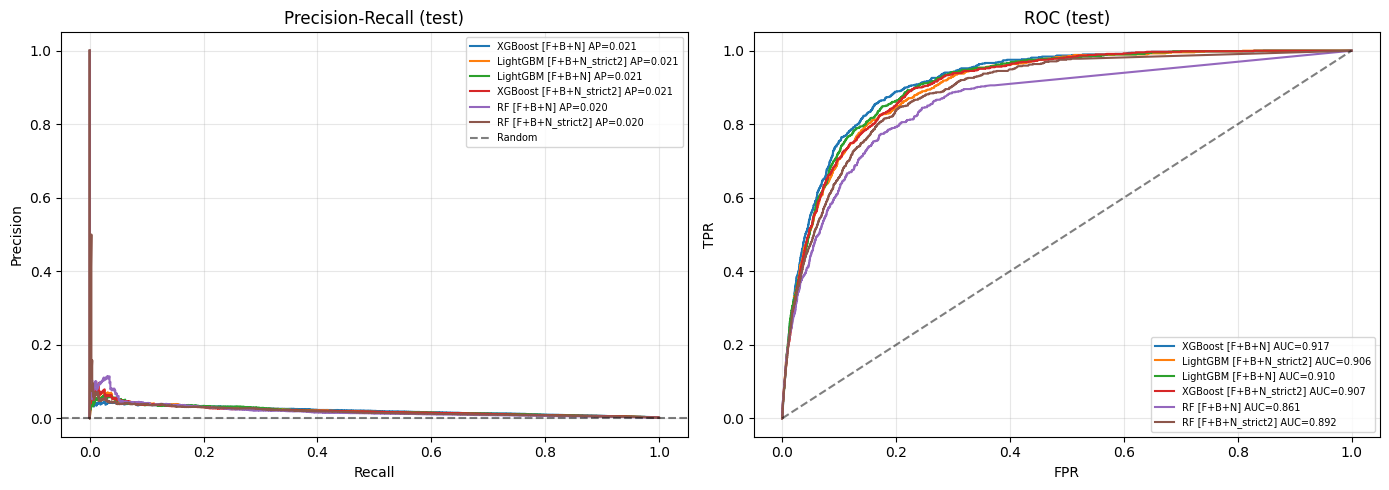

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = results_df.head(6)
colors = plt.cm.tab10.colors

ax = axes[0]; ax.set_title("Precision-Recall (test)")
for i, (_, row) in enumerate(top.iterrows()):
    k = f"{row['Model']}__{row['Features']}"
    if k not in probs_test: continue
    prec, rec, _ = precision_recall_curve(y_te, probs_test[k])
    ap = average_precision_score(y_te, probs_test[k])
    ax.plot(rec, prec, lw=1.5, color=colors[i % len(colors)],
            label=f"{row['Model']} [{row['Features']}] AP={ap:.3f}")
ax.axhline(y_te.mean(), ls="--", color="black", alpha=0.5, label="Random")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.3)

ax = axes[1]; ax.set_title("ROC (test)")
for i, (_, row) in enumerate(top.iterrows()):
    k = f"{row['Model']}__{row['Features']}"
    if k not in probs_test: continue
    fpr, tpr, _ = roc_curve(y_te, probs_test[k])
    auc = roc_auc_score(y_te, probs_test[k])
    ax.plot(fpr, tpr, lw=1.5, color=colors[i % len(colors)],
            label=f"{row['Model']} [{row['Features']}] AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "pr_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


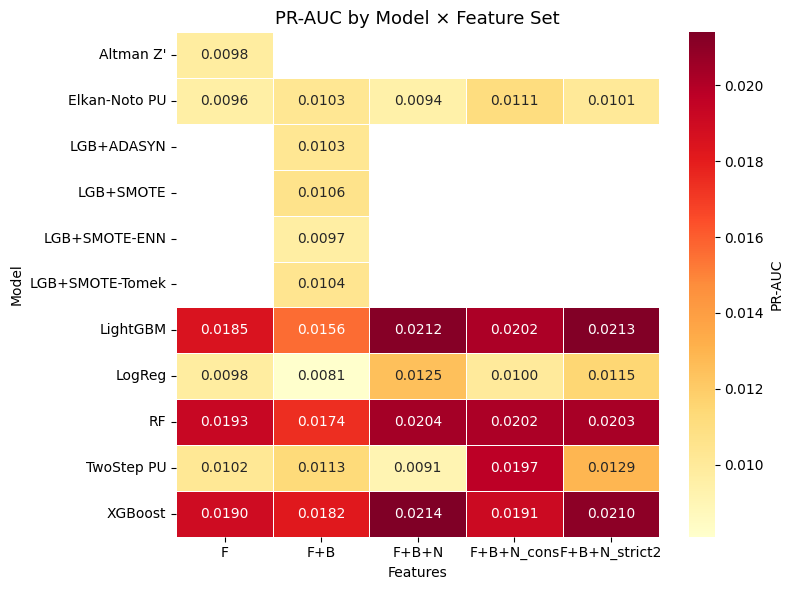

In [ ]:

pivot = results_df.pivot_table(index="Model", columns="Features",
                               values="PR-AUC", aggfunc="first")

pivot = pivot[[c for c in FEATURES.keys() if c in pivot.columns]]
fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "PR-AUC"}, ax=ax)
ax.set_title("PR-AUC by Model × Feature Set", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "results_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


## Phase 14 — SHAP for the best explainable model

The best model by test PR-AUC is refitted with its own model family and stored hyperparameters when possible. If the best run is a PU or resampling wrapper, SHAP is reported as a clearly labelled LightGBM surrogate on the same featureset.


Best model: XGBoost__F+B+N  PR-AUC=0.0214

Top features by SHAP:
             feature  mean_|SHAP| featureset explained_model  surrogate_used
      laat_ratio_cum     1.043329      F+B+N         XGBoost           False
            leverage     0.851758      F+B+N         XGBoost           False
           move_rate     0.787642      F+B+N         XGBoost           False
                 roa     0.593642      F+B+N         XGBoost           False
    filing_days_norm     0.404414      F+B+N         XGBoost           False
     n_directorships     0.332883      F+B+N         XGBoost           False
           current_r     0.302044      F+B+N         XGBoost           False
          fin_debt_r     0.291655      F+B+N         XGBoost           False
                size     0.283885      F+B+N         XGBoost           False
                 age     0.225019      F+B+N         XGBoost           False
               wc_ta     0.218328      F+B+N         XGBoost           False
    has_net

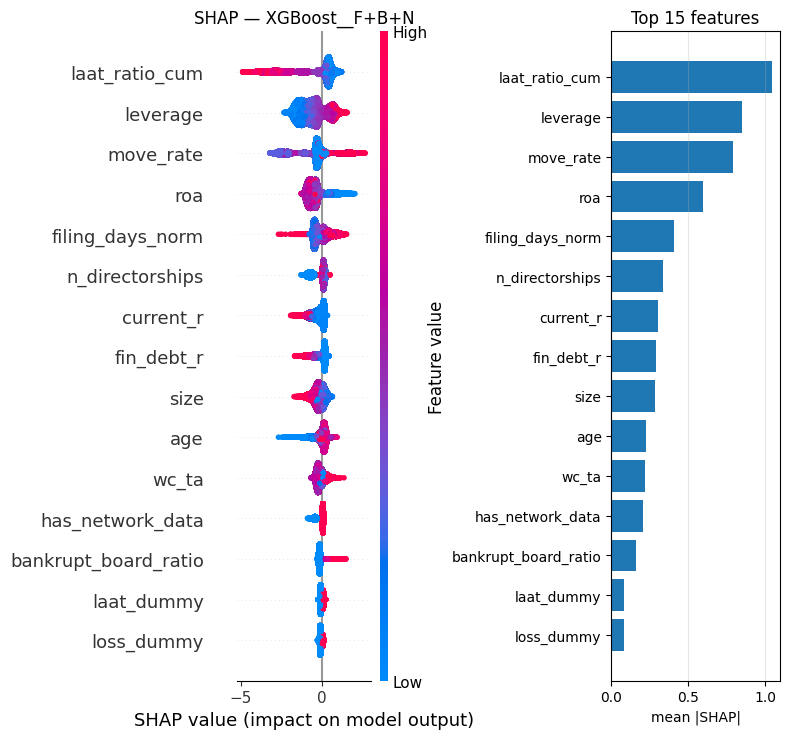

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings, os, json
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
from statsmodels.stats.contingency_tables import mcnemar


best_row = results_df.iloc[0]
best_key = f"{best_row['Model']}__{best_row['Features']}"
print(f"Best model: {best_key}  PR-AUC={best_row['PR-AUC']}")

best_featset = best_row["Features"]
X_tr, y_tr_, X_va, y_va_, X_te, y_te_, _ = data_by_feat[best_featset]
feat_names = FEATURES[best_featset]


model_name = best_row["Model"]
try:
    params = json.loads(best_row.get("best_params", "") or "{}")
except Exception:
    params = {}

surrogate = False
if model_name == "RF":
    shap_model = RandomForestClassifier(**params, class_weight="balanced",
                                        n_jobs=-1, random_state=SEED)
elif model_name == "XGBoost":
    spw = float((len(y_tr_) - y_tr_.sum()) / max(1, y_tr_.sum()))
    shap_model = xgb.XGBClassifier(**params, scale_pos_weight=spw,
                                   eval_metric="aucpr", n_jobs=-1,
                                   random_state=SEED)
elif model_name == "LightGBM":
    shap_model = lgb.LGBMClassifier(**params, class_weight="balanced",
                                    n_jobs=-1, random_state=SEED, verbose=-1)
elif model_name == "LogReg":
    shap_model = LogisticRegression(class_weight="balanced", max_iter=1000,
                                    random_state=SEED)
else:
    surrogate = True
    shap_model = lgb.LGBMClassifier(n_estimators=300, num_leaves=40,
                                    learning_rate=0.05, subsample=0.8,
                                    class_weight="balanced", random_state=SEED,
                                    n_jobs=-1, verbose=-1)
    print(f"SHAP fallback: {model_name} is a wrapper; fitting a LightGBM surrogate on {best_featset}.")


fit_kwargs = {}
if isinstance(shap_model, lgb.LGBMClassifier):
    fit_kwargs = {
        "eval_set": [(X_va, y_va_)],
        "callbacks": [lgb.early_stopping(20, verbose=False),
                      lgb.log_evaluation(-1)],
    }
if isinstance(shap_model, xgb.XGBClassifier):
    fit_kwargs = {"verbose": False}
shap_model.fit(X_tr, y_tr_, **fit_kwargs)


if isinstance(shap_model, LogisticRegression):
    explainer = shap.LinearExplainer(shap_model, X_tr)
    shap_vals = explainer.shap_values(X_te)
else:
    explainer = shap.TreeExplainer(shap_model)
    shap_vals = explainer.shap_values(X_te)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    if len(shap_vals.shape) == 3 and shap_vals.shape[2] == 2:
        shap_vals = shap_vals[:, :, 1]

mean_shap = np.abs(shap_vals).mean(axis=0)
top_idx = np.argsort(mean_shap)[-15:]
shap_table = pd.DataFrame({
    "feature": [feat_names[i] for i in top_idx[::-1]],
    "mean_|SHAP|": mean_shap[top_idx[::-1]],
    "featureset": best_featset,
    "explained_model": model_name,
    "surrogate_used": surrogate,
})
print("\nTop features by SHAP:")
print(shap_table.to_string(index=False))
shap_csv = os.path.join(OUT_DIR, "shap_top_features.csv")
shap_table.to_csv(shap_csv, index=False)
print(f"Saved → {shap_csv}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_te, feature_names=feat_names,
                  show=False, max_display=15)
axes[0].set_title(("SHAP surrogate — " if surrogate else "SHAP — ") + best_key, fontsize=12)
axes[1].barh([feat_names[i] for i in top_idx], mean_shap[top_idx])
axes[1].set_xlabel("mean |SHAP|"); axes[1].set_title("Top 15 features")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "shap_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

## Phase 15 — Sensitivity analysis of the network block

Compare the incremental PR-AUC gain when moving from F+B to F+B+N and
F+B+N_conservative across model families.  This supports the thesis claim
that the network gain is real (or, alternatively, that it is fragile and
driven by potentially leaky features).

In [ ]:

sens = (results_df.pivot_table(index="Model", columns="Features",
                                values="PR-AUC", aggfunc="first")
                   .reindex(columns=["F", "F+B", "F+B+N",
                                     "F+B+N_cons", "F+B+N_strict2"]))
sens["Δ (F+B+N − F+B)"]         = sens["F+B+N"]         - sens["F+B"]
sens["Δ (F+B+N_cons − F+B)"]    = sens["F+B+N_cons"]    - sens["F+B"]
sens["Δ (F+B+N_strict2 − F+B)"] = sens["F+B+N_strict2"] - sens["F+B"]
print("Sensitivity — PR-AUC by featureset (and incremental vs. F+B):")
print(sens.round(4).to_string())
sens.to_csv(os.path.join(OUT_DIR, "network_sensitivity.csv"))


Sensitivity — PR-AUC by featureset (and incremental vs. F+B):
Features              F     F+B   F+B+N  F+B+N_cons  F+B+N_strict2  Δ (F+B+N − F+B)  Δ (F+B+N_cons − F+B)  Δ (F+B+N_strict2 − F+B)
Model                                                                                                                             
Altman Z'        0.0098     NaN     NaN         NaN            NaN              NaN                   NaN                      NaN
Elkan-Noto PU    0.0096  0.0103  0.0094      0.0111         0.0101          -0.0009                0.0008                  -0.0002
LGB+ADASYN          NaN  0.0103     NaN         NaN            NaN              NaN                   NaN                      NaN
LGB+SMOTE           NaN  0.0106     NaN         NaN            NaN              NaN                   NaN                      NaN
LGB+SMOTE-ENN       NaN  0.0097     NaN         NaN            NaN              NaN                   NaN                      NaN
LGB+SMOTE-Tomek     N

## Phase 16 — Final summary

In [ ]:
print("=" * 90)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 90)
print(f"Test set: bookyear {TEST_YEAR} | {len(y_te):,} obs | "
      f"{int(y_te.sum()):,} positives ({y_te.mean() * 100:.3f}%)")
print()
for cat, models in {
    "Baseline (rule)":       ["Altman Z'"],
    "Baseline (supervised)": ["LogReg"],
    "Supervised ML":         ["RF","XGBoost","LightGBM"],
    "SMOTE variants":        [m for m in results_df["Model"].unique()
                              if ("SMOTE" in m) or ("ADASYN" in m)],
    "PU-Learning":           ["Elkan-Noto PU","TwoStep PU"],
}.items():
    sub = results_df[results_df["Model"].isin(models)]
    if len(sub):
        best = sub.loc[sub["PR-AUC"].idxmax()]
        print(f"  {cat:<25} best: {best['Model']} [{best['Features']:<11}]  "
              f"PR-AUC={best['PR-AUC']:.4f}  ROC-AUC={best['ROC-AUC']:.4f}")

print()
print("Artifacts saved to OUT_DIR:")
for fn in ["cleaning_audit.csv", "split_audit.csv",
           "altman_imputation_audit.csv",
           "bankruptcy_results.csv", "features_used.json",
           "network_sensitivity.csv", "shap_top_features.csv",
           "pr_roc_curves.png", "results_heatmap.png", "shap_importance.png"]:
    p = os.path.join(OUT_DIR, fn)
    print(f"  {fn:<28} {'✓' if os.path.exists(p) else '—'}")
print("Notebook complete ✓")


FINAL EXPERIMENT SUMMARY
Test set: bookyear 2019 | 409,702 obs | 690 positives (0.168%)

  Baseline (rule)           best: Altman Z' [F          ]  PR-AUC=0.0098  ROC-AUC=0.7945
  Baseline (supervised)     best: LogReg [F+B+N      ]  PR-AUC=0.0125  ROC-AUC=0.8581
  Supervised ML             best: XGBoost [F+B+N      ]  PR-AUC=0.0214  ROC-AUC=0.9171
  SMOTE variants            best: LGB+SMOTE [F+B        ]  PR-AUC=0.0106  ROC-AUC=0.8538
  PU-Learning               best: TwoStep PU [F+B+N_cons ]  PR-AUC=0.0197  ROC-AUC=0.8983

Artifacts saved to OUT_DIR:
  cleaning_audit.csv           ✓
  split_audit.csv              ✓
  altman_imputation_audit.csv  ✓
  bankruptcy_results.csv       ✓
  features_used.json           ✓
  network_sensitivity.csv      ✓
  shap_top_features.csv        ✓
  pr_roc_curves.png            ✓
  results_heatmap.png          ✓
  shap_importance.png          ✓
Notebook complete ✓
